# Unlocking Revenue Growth: Customer Segmentation, Product Insights & Sales Trends in Online Retail

## Overview
This project analyses an online retail dataset to uncover key business insights related to revenue performance, customer behaviour, and product trends.

Through data cleaning, exploratory data analysis, and customer segmentation techniques, the project aims to identify high-value customers, top-performing products, and patterns in purchasing behaviour over time.

Additionally, the analysis explores cancellations and returns to assess their impact on revenue and identify potential areas for operational improvement.

The insights generated from this analysis can support data-driven decision-making in areas such as marketing strategy, inventory management, and customer retention.

## Objectives
- Analyse overall revenue performance and identify key drivers of sales
- Identify top-performing products and high-revenue transactions
- Understand customer purchasing behaviour and frequency
- Segment customers using RFM analysis to identify high-value groups
- Detect trends and seasonality in sales across different time periods
- Evaluate the impact of cancellations and returns on business revenue
- Identify geographic patterns in sales and customer activity
- Explore product relationships through basket (pairing) analysis

## Tools & Libraries
- Python: core programming language used for analysis
- pandas: data manipulation and cleaning
- NumPy: numerical computations
- Matplotlib: data visualisation
- Seaborn: advanced statistical visualisations
- itertools: generating product combinations for basket analysis

## Dataset
#### Variable Name | Role | Type |Description | Units | Missing Values

InvoiceNo | ID	| Categorical | a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation | no

StockCode | ID | Categorical | a 5-digit integral number uniquely assigned to each distinct product | no

Description	| Feature | Categorical	product name | no

Quantity | Feature | Integer | the quantities of each product (item) per transaction | no

InvoiceDate | Feature | Date | the day and time when each transaction was generated | no

UnitPrice | Feature	| Continuous | product price per unit | sterling | no

CustomerID | Feature | Categorical | a 5-digit integral number uniquely assigned to each customer | no

Country | Feature | Categorical | the name of the country where each customer resides | no

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Read dataset
df = pd.read_excel("Online Retail.xlsx")

In [3]:
# Understanding the data
print(f"Dataset shape (rows, columns): {df.shape} \n")
print(df.info())
df.head()

Dataset shape (rows, columns): (541909, 8) 

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Cleaning & Preprocessing

This section prepares the raw dataset for analysis by handling missing values, correcting data types, and removing inconsistencies such as cancelled transactions.

In [5]:
# Adding a 'Revenue' column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [6]:
# Splitting 'InvoiceDate' column
df['Date'] = df['InvoiceDate'].dt.normalize()
df['Year'] = df['InvoiceDate'].dt.year
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Month'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

In [7]:
# Adding an OrderStatus column
df['OrderStatus'] = df['InvoiceNo'].astype(str).str.startswith('C')
df['OrderStatus'] = df['OrderStatus'].map({True: 'Cancelled', False: 'Purchased'})

In [8]:
# Count rows containing 'Adjust'
adjust_rows = df['Description'].str.contains('Adjust', case=False, na=False)
print("Number of rows containing 'Adjust': ", adjust_rows.sum())

# Remove rows where Description contains 'Adjust' 
df = df[~df['Description'].str.contains('Adjust', case=False, na=False)].copy() 

Number of rows containing 'Adjust':  34


In [9]:
# Count UnitPrice = 0 rows
zero_price_rows = (df['UnitPrice'] == 0)
print("Number of rows with UnitPrice = 0: ", zero_price_rows.sum())

# Remove all rows where UnitPrice is £0
df = df[df['UnitPrice'] != 0].copy()

Number of rows with UnitPrice = 0:  2484


In [10]:
# Total number of rows removed
rows_to_remove = (zero_price_rows | adjust_rows).sum()
print("Total number of rows removed: ", rows_to_remove)

# Total percentage of rows removed
zero_adjust_percentage = ((rows_to_remove / df.shape[0]) * 100).round(2)
print(f"Total percentage of rows removed: {zero_adjust_percentage}%")

Total number of rows removed:  2484
Total percentage of rows removed: 0.46%


In [11]:
# Non-merchandise keywords
keywords = 'POSTAGE|DOTCOM POSTAGE|Manual|CARRIAGE|Next Day Carriage|Bank Charges|Amazon Fee|Discount'

# Remove rows where Description contains keywords
df = df[~df['Description'].str.contains(keywords, case=False, na=False)].copy()

### Revenue
`Revenue` = `Quantity` × `UnitPrice`

This metric represents the total monetary value generated per transaction line.

Creating this feature enables analysis of:
- Revenue contribution by product, country, or customer
- Identification of high-value customers and products
- Average order value and purchasing behaviour

### DateTime Feature Engineering
Splitting the `InvoiceDate` column into seperate time-based components, allows for more granular analysis.

This allows for:
- Evaluation of performance and trends over time (daily, monthly, seasonal trends)
- Identify weekly patterns (e.g., high and low sales days)
- Understanding customer activity with peak purchasing hours

### OrderStatus
Invoices starting with 'C' indicate cancelled orders. This feature identifies whether an invoice represents a cancellation or a completed purchase.

This allows analysis of:
- Cancellation rate
- Revenue lost from cancellations
- Customer cancellation patterns

### Missing `Customer ID` values
`CustomerID` values for each transaction should ideally be linked to a customer.  

The dataset contains 541,909 rows, of which 135,080 have missing CustomerID values. Removing these would significantly reduce the dataset and risk introducing bias into revenue and trend analysis. As most aggregation functions exclude null values by default, these records were retained for overall analysis. However, customer-level insights were limited to records with valid CustomerIDs.

### Initial Exploratory Data Analysis (EDA)
During EDA, it was observed that when subsetting to purchased transactions, the `Revenue` column contained negative values. These values should correspond to cancellations. Investigation revealed that these rows were labeled as ‘Adjust bad debt’, with `InvoiceID`s starting with ‘A’. To prevent skewing transaction-level analyses, all rows with descriptions containing ‘Adjust’ were removed, as they represented financial adjustments recorded as invoices rather than genuine sales.

After removing negative values, the minimum Revenue value was £0. Further inspection of the `UnitPrice` and `Description` columns revealed that many of these zero-value transactions also had missing or uninformative product descriptions. Qualitative analysis showed these records often contained descriptions such as ‘missing’ or ‘smashed’, representing internal stock adjustments or corrupted system entries rather than actual customer purchases.

Consequently, transactions with zero `UnitPrice` were removed. This step removed 2,518 rows out of over 500,000, removing all non-descriptive product entries. Excluding these ensures the dataset reflects genuine commercial activity and provides a reliable basis for revenue and customer behaviour analysis.

Only 0.46% of rows were removed, representing a minimal impact on the overall dataset.

### Further Analysis
During the analysis of highest-earning products based on Revenue, it became evident that entries such as 'POSTAGE' appeared among the top contributors. These entries were identified as non-merchandise and therefore required removal to ensure accurate product-level insights.

Specifically, 'POSTAGE' showed a significantly higher average UnitPrice compared to typical products, indicating it behaves differently from standard retail items. This is expected, as postage costs are order-level charges influenced by factors such as weight, size, delivery distance, and whether the shipment is domestic or international. As a result, including such entries would distort revenue analysis and product rankings.

A detailed review of the Description field was conducted to identify and exclude all non-merchandise rows. For example:
- 'Manual' entries were interpreted as manually inputted adjustments or corrections rather than actual sales. This was further supported by the observation that they exhibited one of the highest average UnitPrice values among top-performing entries, reinforcing that they do not behave like standard retail products.
- 'CARRIAGE' initially required further investigation; however, inconsistencies in its StockCode format (e.g., shorter length than expected) confirmed it does not represent a legitimate product.
- Additional entries related to fees, charges, or operational adjustments were also removed, as they do not reflect customer-driven product purchases.

By filtering out these non-merchandise records, the dataset was refined to better represent genuine product sales, leading to more reliable revenue analysis and insights.

During the analysis of cancelled transactions, a data quality issue was identified where 'Discount' entries had not been fully excluded during data cleaning. This was addressed and resolved, improving the overall accuracy and reliability of the analysis.

## Exploratory Data Analysis

This section explores the dataset to uncover patterns in revenue, customer activity, product performance, and time-based behaviour. Key trends and distributions are analysed to identify potential drivers of sales and operational insights. These findings provide a foundation for deeper analysis and support data-driven business decision-making.

### Revenue Analysis

Revenue generation is a central objective in retail, and understanding how it is driven is key to informing effective business strategy. To uncover these patterns, revenue is analysed in relation to multiple factors, including invoice-level transactions, customer purchasing behaviour, geographic location, and time-based trends. This multi-dimensional approach enables deeper insight into where and how revenue is generated, supporting more targeted and data-driven decision-making.

In [12]:
# Distribution by row (transaction of an item)
rev = df['Revenue'].mean()
print("Average revenue by row (all data): ", rev.round(2))

# Split data (Purchased vs Cancelled | Positive vs Negative)
purchased = df[df['OrderStatus'] == 'Purchased']
cancelled = df[df['OrderStatus'] == 'Cancelled']

# Purchased summary
print("\nPurchased transactions:")
print("Count:", len(purchased))
print("Mean:", purchased['Revenue'].mean().round(2))
print("Median:", purchased['Revenue'].median())
print("Max:", purchased['Revenue'].max())
print("Min:", purchased['Revenue'].min())

# Cancelled summary
print("\nCancelled transactions:")
print("Count:", len(cancelled))
print("Mean:", cancelled['Revenue'].mean().round(2))
print("Median:", cancelled['Revenue'].median())
print("Max:", cancelled['Revenue'].max())
print("Min:", cancelled['Revenue'].min())

Average revenue by row (all data):  18.23

Purchased transactions:
Count: 527621
Mean: 19.46
Median: 9.9
Max: 168469.6
Min: 0.001

Cancelled transactions:
Count: 8776
Mean: -55.8
Median: -8.5
Max: -0.12
Min: -168469.6


Although analysing `Revenue` on its own does not yield direct business insights, it helps establish key patterns that guide the broader exploratory analysis.

A mean revenue of £19.46 per transaction compared to a median of £9.90 indicates a right-skewed distribution, where most transactions are relatively low value. High-value outliers inflate the average, making it important to consider both mean and median when interpreting transaction data.

A maximum transaction value of £168,469.60 further highlights the presence of extreme outliers, likely representing bulk or wholesale purchases that disproportionately influence overall revenue.

Cancelled transactions show a different pattern, with a mean of -£55.96 and a median of -£8.50. This suggests that returns tend to involve higher-value transactions compared to typical purchases. Although cancellations are less frequent, their larger magnitude means they have a noticeable impact on overall revenue.

In [13]:
# Negative values in the purchased subset (data now cleaned)
purchased_negative = purchased[purchased['Revenue'] < 0]
purchased_negative

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date,Year,YearMonth,Month,Day,Hour,DayOfWeek,OrderStatus


The minimum value in the purchased DataFrame was negative. Negative values were associated with cancelled orders, representing financial adjustment records. These transactions were identified and removed from the dataset during the data cleaning process.

In [14]:
# Revenue = 0 values in purchased (data now cleaned)
purchased_zero = purchased[purchased['Revenue'] == 0]
purchased_zero

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date,Year,YearMonth,Month,Day,Hour,DayOfWeek,OrderStatus


In [15]:
# Missing Descriptions in purchased (data now cleaned)
purchased_nan = df[df["Description"].isna()]
purchased_nan

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date,Year,YearMonth,Month,Day,Hour,DayOfWeek,OrderStatus


A second issue emerged after this adjustment: the minimum revenue value was £0. Upon further investigation, these transactions were identified as internal stock adjustments rather than genuine sales. As they did not represent genuine revenue, they were removed from the dataset.

#### Revenue by Invoice

Examines individual transaction values to identify high-value purchases and overall distribution of order sizes.

In [16]:
# Total Revenue per invoice
sum_per_invoice = purchased.groupby('InvoiceNo')['Revenue'].sum()

# Highest Revenue per Invoice
highest_per_invoice = sum_per_invoice.sort_values(ascending=False).head()

# Lowest Revenue per Invoice
lowest_per_invoice = sum_per_invoice.sort_values(ascending=True).head()

# Result
high_low_rev_invoice = pd.concat([highest_per_invoice, lowest_per_invoice], axis=0, keys=['Highest Revenue per Invoice', 'Lowest Revenue per Invoice'])
high_low_rev_invoice

                             InvoiceNo
Highest Revenue per Invoice  581483       168469.60
                             541431        77183.60
                             574941        52940.94
                             576365        50653.91
                             556444        38970.00
Lowest Revenue per Invoice   570554            0.38
                             539441            0.42
                             542736            0.55
                             540833            0.65
                             560217            0.79
Name: Revenue, dtype: float64

In [17]:
# Total Revenue of top 5 Invoices
print(f"Total Revenue of Top 5 Invoices: ", highest_per_invoice.sum().round(2))

Total Revenue of Top 5 Invoices:  388218.05


In [18]:
# Distribution per invoice
print(f"Average revenue distribution per invoice: ", sum_per_invoice.mean().round(2))
print(f"Median revenue distribution per invoice: ", sum_per_invoice.median().round(2))

Average revenue distribution per invoice:  519.32
Median revenue distribution per invoice:  302.57


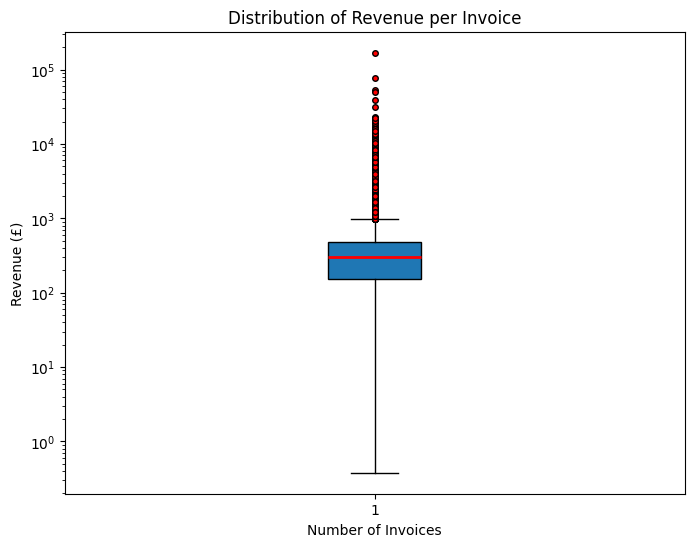

In [19]:
# Plotting Revenue per Invoice
plt.figure(figsize=(8, 6))
plt.boxplot(sum_per_invoice.values, patch_artist=True, flierprops=dict(marker='o', markersize=4, markerfacecolor='red'), 
            medianprops=dict(color='red', linewidth=2))
plt.title("Distribution of Revenue per Invoice")
plt.xlabel("Number of Invoices")
plt.ylabel("Revenue (£)")
plt.yscale('log')
plt.show()

In [20]:
# Revenue IQR for Invoices
rev_q1 = np.quantile(sum_per_invoice, 0.25)
rev_q3 = np.quantile(sum_per_invoice, 0.75)
rev_iqr = rev_q3 - rev_q1

# Calculate the lower and upper cutoffs for outliers
rev_lower = rev_q1 - 1.5 * rev_iqr
rev_upper = rev_q3 + 1.5 * rev_iqr

print(f"Revenue by Invoice - 25th percentile (Q1): ", rev_q1.round(2))
print(f"Revenue by Invoice - 75th percentile (Q3): ", rev_q3.round(2))
print(f"Revenue by Invoice - Interquartile range (IQR): ", rev_iqr.round(2))
print(f"\nLow outliers must be below: ", rev_lower.round(2))
print(f"High outliers must be above: ", rev_upper.round(2))

Revenue by Invoice - 25th percentile (Q1):  152.29
Revenue by Invoice - 75th percentile (Q3):  483.4
Revenue by Invoice - Interquartile range (IQR):  331.1

Low outliers must be below:  -344.37
High outliers must be above:  980.05


Grouping `Revenue` by `Invoice` shows that most customers make multiple transactions within a single invoice, as mean per transaction is £19.46 and mean per invoice is £519.32. Invoice-level analysis presents a clear disparity, capturing the cumulative effect of multiple transactions per customer.

The interquartile range (IQR) was calculated as the difference between the 75th percentile (Q3) and 25th percentile (Q1) of invoice-level revenue. While the IQR itself is a single value representing the spread of the middle 50% of the data, the boxplot visualises this as the range between Q1 and Q3, with the median shown as a line within the box.

Examining invoice-level revenue further, the middle 50% of invoices fall between £152.29 (Q1) and £483.40 (Q3), giving an interquartile range (IQR) of £331.10. This range represents the typical spending per invoice, with the median providing a robust measure showing the typical spending per invoice. The calculated low outlier threshold (-£344.37) is below zero, confirming there are no unusually low invoices, while the high outlier threshold (£980.05) highlights a small number of very high-value invoices, likely due to bulk purchases or large orders.

Most customer invoices fall within a predictable spending range. However, the outliers signficantly impact the overall revenue resulting in right-skewed data. This highlights the importance of analysis through IQR and median. Evidence of high-value invoices skewing revenue is shown by the top 5 invoices totalling £388,218, with the 5th highest invoice exceeding £38,000.

#### Revenue by Month

Analyses monthly revenue trends to identify seasonality and fluctuations in sales performance.

In [21]:
# Revenue by Month
rev_per_month = purchased.groupby('YearMonth')['Revenue'].sum().round(2)
rev_per_month

YearMonth
2010-12     778008.36
2011-01     671817.06
2011-02     508952.87
2011-03     691265.94
2011-04     516339.79
2011-05     741134.39
2011-06     738448.70
2011-07     689138.00
2011-08     725423.61
2011-09    1030216.74
2011-10    1106445.41
2011-11    1457212.47
2011-12     615220.44
Freq: M, Name: Revenue, dtype: float64

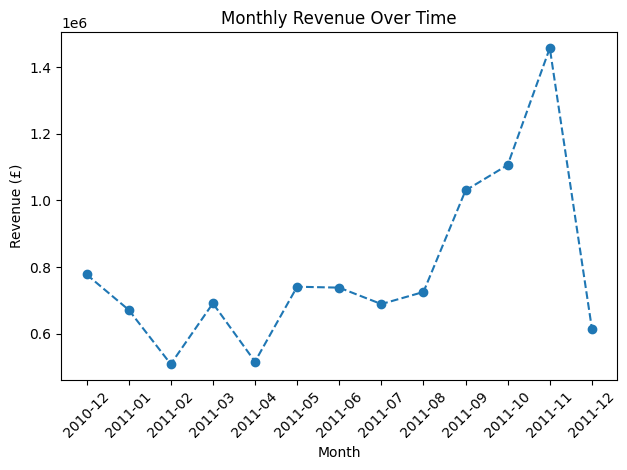

In [22]:
# Plotting Revenue by Month
plt.plot(rev_per_month.index.astype(str), rev_per_month.values, marker='o', linestyle='--')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Over Time")
plt.ylabel("Revenue (£)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

Analysing `Revenue` by `Month` provides valuable insights into seasonal demand patterns. While the dataset only covers a single year, so comparisons across years are not possible, it still allows for generalised insights.

The data shows clear revenue spikes in September, October, and November, corresponding to the run up to the Christmas period. This indicates strong seasonal demand, further reinforced by the fact that the majority of orders originate from the UK and other European countries.

In contrast, the early months of the year generally show lower revenue, likely due to reduced consumer spending following the festive season. February and April, in particular, demonstrate the most significant dips in revenue.

Business Implications:
- To mitigate low-revenue periods, the business could implement flash sales, targeted discount promotions, or loyalty incentives to encourage spending in slower months.
- Understanding these seasonal patterns can help in inventory planning, marketing campaigns, and resource allocation, ensuring that high-demand periods are fully capitalised while slow periods are strategically supported.

#### Revenue by Customer

Identifies high-value customers based on total spending to support customer value segmentation.

In [23]:
# Total Revenue by Customer
rev_per_cust = purchased.groupby('CustomerID')['Revenue'].sum().reset_index()

# Find 90th percentile threshold
threshold = rev_per_cust['Revenue'].quantile(0.9)

# Filter top 10% customers
top_customers = rev_per_cust[rev_per_cust['Revenue'] >= threshold]

# DataFrame of top 10%
top_10_percent_cust = purchased[purchased['CustomerID'].isin(top_customers['CustomerID'])]

In [24]:
# Revenue by Customer statistics
rev_per_cust['Revenue'].describe().round(2)

count      4334.00
mean       2020.96
std        8906.99
min           3.75
25%         305.56
50%         668.08
75%        1631.62
max      279138.02
Name: Revenue, dtype: float64

Text(0, 0.5, 'Number of Customers')

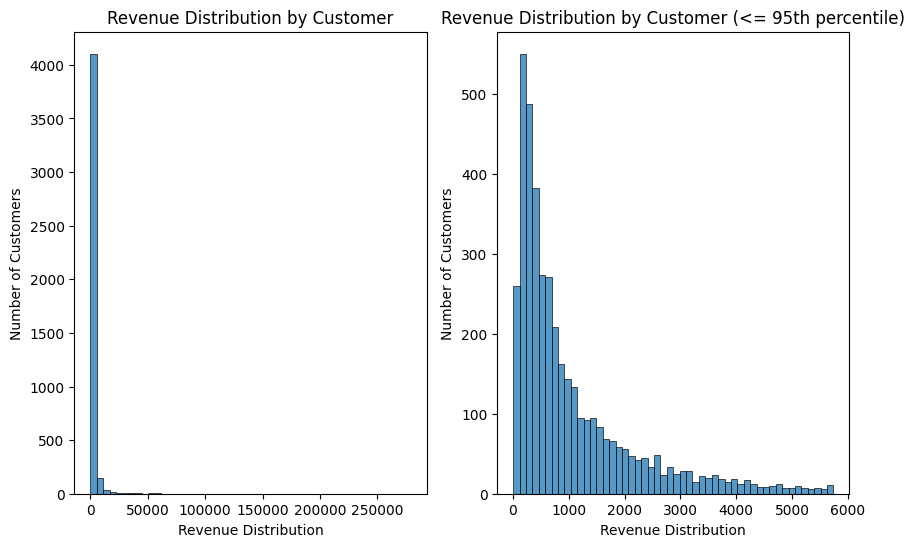

In [25]:
# Plotting Revenue by Customer
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Revenue by Customer
sns.histplot(data=rev_per_cust, x='Revenue', bins=50, ax=axes[0])
axes[0].set_title("Revenue Distribution by Customer")
axes[0].set_xlabel("Revenue Distribution")
axes[0].set_ylabel("Number of Customers")

# Revenue by Customer (95th percentile)
upper = rev_per_cust['Revenue'].quantile(0.95)
sns.histplot(rev_per_cust[rev_per_cust['Revenue'] <= upper]['Revenue'], bins=50, ax=axes[1])
axes[1].set_title("Revenue Distribution by Customer (<= 95th percentile)")
axes[1].set_xlabel("Revenue Distribution")
axes[1].set_ylabel("Number of Customers")

In [26]:
# Total Revenue of Top 10%
total_rev_top_cust = top_10_percent_cust['Revenue'].sum()

# Total Revenue of all purchases
total_rev = purchased['Revenue'].sum()

# Percentage Revenue contribution of top 10%
top_10_contribution = ((total_rev_top_cust/total_rev) * 100).round(2)
print(f"Revenue contribution by Top 10% of Customers: {top_10_contribution}%")

Revenue contribution by Top 10% of Customers: 52.32%


Analysing `Revenue` at the customer level (`CustomerID`) provides valuable insight into customer behaviour across different countries. It helps identify whether customers typically purchase high-value products or buy in bulk, and whether they are repeat customers. Combining `Revenue` with `CustomerID` also allows us to assess how the top 10% of revenue-generating customers impact overall revenue and identify which products contribute most to their spend.

The revenue distribution among customers is heavily right-skewed. The average customer spend is £2,020.96, while the median is £668.08, and 75% of customers spent £1,631.62 or less. This demonstrates that a small number of high-value customers disproportionately influence the average revenue. For example, the highest-spending customer alone contributed £279,138.02.

Initial histograms of revenue were distorted by extreme outliers. To better visualise trends, customers above the 95th percentile were trimmed, revealing the right-skew: a large volume of customers spend at lower levels, and as revenue increases, the number of customers declines. Notably, the dominant volume of customers is concentrated in the £0–£1,000 range, representing the majority of the customer base.

Pareto Analysis further highlights this pattern: the top 10% of customers account for over 52% of total revenue, confirming the significant influence of high-value clients.

Business Insights:
- The presence of a small number of high-value customers drives the mean revenue, creating a right-skewed distribution.
- Focusing on this customer segment can significantly increase revenue. Strategies could include:
  - Loyalty programmes to encourage repeat purchases
  - Upselling and cross-selling higher-value products
  - Personalised promotions or VIP offers for top customers

#### Revenue by Country

Explores geographical differences in revenue to identify key markets and regions driving sales.

In [27]:
# Revenue by Country
rev_country_sum = purchased.groupby('Country')['Revenue'].sum()

# Highest Revenue generating countries
highest_rev_country = rev_country_sum.sort_values(ascending=False).round(2).head()

# Lowest Revenue generating countries
lowest_rev_country = rev_country_sum.sort_values(ascending=True).round(2).head()

# Result
high_low_rev_country = pd.concat([highest_rev_country, lowest_rev_country], axis=0, keys=['Highest Revenue by Country', 'Lowest Revenue by Country'])
high_low_rev_country

                            Country       
Highest Revenue by Country  United Kingdom    8745825.48
                            Netherlands        283889.34
                            EIRE               271111.10
                            Germany            205569.89
                            France             184582.74
Lowest Revenue by Country   Saudi Arabia          145.92
                            Bahrain               754.14
                            Czech Republic        786.74
                            RSA                  1002.31
                            Brazil               1143.60
Name: Revenue, dtype: float64

In [28]:
# Mean Revenue by Country
rev_country_mean = purchased.groupby('Country')['Revenue'].mean()
rev_country_mean.sort_values(ascending=False).round(2).head()

Country
Netherlands    122.26
Australia      117.00
Japan          116.56
Sweden          86.07
Denmark         49.62
Name: Revenue, dtype: float64

In [29]:
# Invoice by Country
orders_per_country = purchased.groupby('Country')['InvoiceNo'].nunique()
orders_per_country.sort_values(ascending=False).head()

Country
United Kingdom    17903
Germany             443
France              382
EIRE                282
Belgium              98
Name: InvoiceNo, dtype: int64

In [30]:
# Revenue per Order by Country
country_metrics = purchased.groupby('Country').agg(
    total_revenue=('Revenue','sum'),
    orders=('InvoiceNo','nunique')
)

# Adding a Revenue per Order column
country_metrics['revenue_per_order'] = country_metrics['total_revenue'] / country_metrics['orders']
country_metrics['revenue_per_order'] = country_metrics['revenue_per_order'].round(2)  

country_metrics.head() # Showing first five for readibility

,total_revenue,orders,revenue_per_order
Country,,,
Australia,138171.31,56,2467.34
Austria,8742.68,17,514.28
Bahrain,754.14,3,251.38
Belgium,36927.34,98,376.81
Brazil,1143.60,1,1143.60


Studying `Revenue` by `Country` provides valuable insights for understanding market dynamics, informing pricing strategies, and guiding overall business strategy.

The highest revenue-generating countries are predominantly European, while the lowest are mostly non-European, suggesting the distributor is based in Europe, most likely the UK, which also accounts for the highest volume of invoices.

Some countries, such as Australia, Japan, Sweden, and Denmark, rank highly in transaction-level revenue averages (top 5) but do not appear in the top 5 for total revenue. This indicates these are high-value markets where targeted pricing strategies could be effective.

The UK, as the dominant market, demonstrates high order volume but lower average revenue per order. With an average transaction value of £18.07, the UK achieves high overall revenue through a large number of invoices rather than high-value transactions.

Market strategy: 
- Focus on operaitonal efficiency and volume-driven promotions.
- Encourage repeat purchases through loyalty programmes or bulk purchasing discounts.
- Introduce upselling of complementary items to increase the average revenue per order.

In contrast, the Netherlands represents a high-value market, with an average revenue of £3,052.57 per order. Although it ranks 6th in terms of invoice volume, it is the highest in average revenue per order and per transaction, highlighting the importance of larger, high-value purchases in this market.

Market strategy:
- Targeted marketing on premium to luxury range products.
- Provide extra services or promotions to retain high-value customers.

#### Revenue by Country (Top 10%)

Focuses on high-value customers within each country to understand premium customer distribution geographically.

In [31]:
# Total Revenue by Country for top 10% of customers
total_top10_cust = top_10_percent_cust.groupby('Country')['Revenue'].sum()

# Mean Revenue by Country for top 10% of customers
av_top10_cust = top_10_percent_cust.groupby('Country')['Revenue'].mean()

# Table comparison
total_mean_top_customers = pd.concat([total_top10_cust, av_top10_cust], axis=1, keys=['Total Revenue by Country (top10%)',
                                                                                      'Average Revenue by Country (top10%)'])
total_mean_top_customers.sort_values(by='Total Revenue by Country (top10%)',
                                     ascending=False).round(2).head() # Showing first five for readibility

,Total Revenue by Country (top10%),Average Revenue by Country (top10%)
Country,,
United Kingdom,4234115.77,31.57
Netherlands,279138.02,135.50
EIRE,257243.36,36.07
Australia,130079.20,145.50
Germany,122695.94,28.59


Analysing `Revenue` by `Country` within the top 10% of customers provides useful validation, but does not reveal significantly new patterns compared to the full dataset.

Across both datasets, the UK consistently contributes the highest total revenue, followed by the Netherlands and Ireland. Germany, France, and Australia occupy the next positions, with slight variation in ranking.

In terms of average spend per transaction, Netherlands, Australia, Japan, Sweden, and Denmark consistently rank among the top five, although their exact order varies between datasets.

Japan, Sweden, and Denmark demonstrate some of the highest average spend per transaction, yet contribute only mid-level total revenue. This suggests strong customer value but lower purchase frequency or a smaller customer base.

Market strategy (Japan, Sweden, and Denmark):
- Increase purchase frequency: Encourage repeat purchases through retention strategies such as email remarketing, loyalty programmes, and timely reminders.
- Improve market penetration: Expand the customer base using localised marketing, targeted advertising, and strategic partnerships within these regions.
- Simplify and optimise delivery incentives: Introduce attractive shipping thresholds or delivery perks to encourage customers to purchase more frequently.

#### Top Performing Products (Top 10%)

Identifies products generating the highest revenue to highlight key drivers of business performance.

In [32]:
# Top 10 Revenue earning products among the top 10% of customers
top_products = top_10_percent_cust.groupby('Description')['Revenue'].sum().reset_index().sort_values(by='Revenue',
                                                                                                     ascending=False).iloc[:10]
top_products

,Description,Revenue
2108,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2513,REGENCY CAKESTAND 3 TIER,103538.85
1806,MEDIUM CERAMIC TOP STORAGE JAR,80069.63
3389,WHITE HANGING HEART T-LIGHT HOLDER,66968.00
1596,JUMBO BAG RED RETROSPOT,62964.32
2134,PARTY BUNTING,41150.83
2180,PICNIC BASKET WICKER 60 PIECES,39619.50
648,CHILLI LIGHTS,38449.96
2403,RABBIT NIGHT LIGHT,37621.73
193,ASSORTED COLOUR BIRD ORNAMENT,32865.97


In [33]:
# DataFrame of the top 10 products
top_products_df = top_10_percent_cust[top_10_percent_cust['Description'].isin(top_products['Description'])]

# UnitPrice of the top products
top_products_df[['Description', 'UnitPrice']].drop_duplicates().head() # Showing first five for readibility

,Description,UnitPrice
0,WHITE HANGING HEART T-LIGHT HOLDER,2.55
177,JUMBO BAG RED RETROSPOT,1.65
178,CHILLI LIGHTS,3.82
265,ASSORTED COLOUR BIRD ORNAMENT,1.69
880,REGENCY CAKESTAND 3 TIER,10.95


In [34]:
# Average UnitPrice of the top 10 products
top_products_df.groupby('Description')['UnitPrice'].mean().reset_index().round(2)

,Description,UnitPrice
0,ASSORTED COLOUR BIRD ORNAMENT,1.67
1,CHILLI LIGHTS,5.40
2,JUMBO BAG RED RETROSPOT,1.99
3,MEDIUM CERAMIC TOP STORAGE JAR,1.20
4,"PAPER CRAFT , LITTLE BIRDIE",2.08
5,PARTY BUNTING,4.83
6,PICNIC BASKET WICKER 60 PIECES,649.50
7,RABBIT NIGHT LIGHT,2.01
8,REGENCY CAKESTAND 3 TIER,12.29
9,WHITE HANGING HEART T-LIGHT HOLDER,2.85


In [35]:
# Number of unique products (data now cleaned)
prod_descriptions = purchased['Description'].unique()
len(prod_descriptions)

4016

In [36]:
# List all products to check for non-merchandise items/services (data now cleaned)
for desc in purchased['Description'].unique():
    print(desc)

WHITE HANGING HEART T-LIGHT HOLDER
WHITE METAL LANTERN
CREAM CUPID HEARTS COAT HANGER
KNITTED UNION FLAG HOT WATER BOTTLE
RED WOOLLY HOTTIE WHITE HEART.
SET 7 BABUSHKA NESTING BOXES
GLASS STAR FROSTED T-LIGHT HOLDER
HAND WARMER UNION JACK
HAND WARMER RED POLKA DOT
ASSORTED COLOUR BIRD ORNAMENT
POPPY'S PLAYHOUSE BEDROOM 
POPPY'S PLAYHOUSE KITCHEN
FELTCRAFT PRINCESS CHARLOTTE DOLL
IVORY KNITTED MUG COSY 
BOX OF 6 ASSORTED COLOUR TEASPOONS
BOX OF VINTAGE JIGSAW BLOCKS 
BOX OF VINTAGE ALPHABET BLOCKS
HOME BUILDING BLOCK WORD
LOVE BUILDING BLOCK WORD
RECIPE BOX WITH METAL HEART
DOORMAT NEW ENGLAND
JAM MAKING SET WITH JARS
RED COAT RACK PARIS FASHION
YELLOW COAT RACK PARIS FASHION
BLUE COAT RACK PARIS FASHION
BATH BUILDING BLOCK WORD
ALARM CLOCK BAKELIKE PINK
ALARM CLOCK BAKELIKE RED 
ALARM CLOCK BAKELIKE GREEN
PANDA AND BUNNIES STICKER SHEET
STARS GIFT TAPE 
INFLATABLE POLITICAL GLOBE 
VINTAGE HEADS AND TAILS CARD GAME 
SET/2 RED RETROSPOT TEA TOWELS 
ROUND SNACK BOXES SET OF4 WOODLAND 
SPA

In [37]:
# Checking CARRIAGE (data now cleaned)
carriage = purchased[purchased['Description'] == 'CARRIAGE']
carriage.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date,Year,YearMonth,Month,Day,Hour,DayOfWeek,OrderStatus


##### Data Quality Note
During the initial analysis of top ten products, several non-merchandise entries (e.g. postage, adjustments) appeared among the highest-ranking items.

This indicated that the dataset included operational or administrative entries that could distort product-level insights. As a result, these items were identified and removed to ensure the analysis reflects genuine product demand.

(Full details of this cleaning step are documented in the Data Cleaning & Preprocessing section.)

##### Findings
The top 10% of customers contribute over half of total revenue and represent the most valuable and frequently returning segment. Analysing the products they purchase provides insight into how high revenue is generated, whether through high-value items or high-volume (bulk) purchasing behaviour.

By combining `Description` (product) with total revenue, the top 10 revenue-generating products were identified. These were then analysed alongside `UnitPrice` to determine whether revenue was driven by expensive items or frequently purchased lower-cost products.

Due to price variation across transactions for the same product, the average `UnitPrice` was calculated to provide a more reliable measure of product value.

The highest revenue-generating product, 'PAPER CRAFT, LITTLE BIRDIE', has a relatively low average unit price of £2.08, indicating that its strong revenue contribution is driven by high-volume purchasing rather than high individual value.

Overall, pricing patterns across the top 10 products show:
- 60% of products have an average price of £2.85 or lower
- 20% fall within the £4.50–£5.50 range
- One product averages £12.29
- One standout high-value product averages £649.50

This distribution clearly indicates that most revenue is generated through low-cost items purchased in large quantities, with only limited contribution from high-value products.

Market strategy:
- Encourage bulk purchasing behaviour: Introduce volume-based incentives such as multi-buy offers, tiered discounts, or bundle deals to further drive large-quantity purchases.
- Promote high-demand, low-cost products: Prioritise visibility of these items in marketing campaigns, as they are proven to generate significant revenue through repeat and bulk purchases.

#### Customer Segmentation

Groups customers based on purchasing behaviour to identify distinct value segments for targeting.

In [38]:
# Splitting customers into segments by four quantiles
rev_per_cust['Segment'] = pd.qcut(rev_per_cust['Revenue'], q=4, labels=['Low Value', 'Medium Value', 'High Value', 'VIP'])

In [39]:
# Sum Revenue by Segment
sum_seg = rev_per_cust.groupby('Segment')['Revenue'].sum().round(2)
sum_seg

Segment
Low Value        192386.35
Medium Value     496405.26
High Value      1144603.60
VIP             6925462.87
Name: Revenue, dtype: float64

In [40]:
# Calculating the revenue contribution of the bottom 75% of customers relative to the top 25% (VIP) customers
percentage_rev_compare = (((sum_seg['Low Value'] + sum_seg['Medium Value'] + sum_seg['High Value']) / sum_seg['VIP']) * 100).round(2)

print(f"The bottom 75% of customers contribute only {percentage_rev_compare}% as much revenue as the top 25% (VIP) customers.")

The bottom 75% of customers contribute only 26.47% as much revenue as the top 25% (VIP) customers.


In [41]:
# Mean Revenue by Segment
rev_per_cust.groupby('Segment')['Revenue'].mean().round(2)

Segment
Low Value        177.48
Medium Value     458.36
High Value      1056.88
VIP             6388.80
Name: Revenue, dtype: float64

In [42]:
# Joining 'Segment' column to purchased DataFrame
purchased = purchased.merge(rev_per_cust[['CustomerID', 'Segment']], on='CustomerID', how='left')

# Orders per Segment
orders_seg = purchased.groupby('Segment')['InvoiceNo'].nunique()
orders_seg

Segment
Low Value        1358
Medium Value     2023
High Value       3770
VIP             11251
Name: InvoiceNo, dtype: int64

In [43]:
# Number VIP orders vs the rest
bottom_75 = orders_seg['Low Value'] + orders_seg['Medium Value'] + orders_seg['High Value']
top_25 = orders_seg['VIP']

print(f"The top 25% (VIP) ordered a total of {top_25} times, whereas the bottom 75% made just {bottom_75} orders.")

The top 25% (VIP) ordered a total of 11251 times, whereas the bottom 75% made just 7151 orders.


Given that the top 10% of customers contribute a significant share of total revenue, it is equally important to understand the contribution of lower and mid-value customer segments.

Customers were segmented into four quantiles based on `Revenue`, resulting in the following groups:
- Low Value
- Medium Value
- High Value
- VIP

While it is expected that average revenue increases across these segments, further analysis was conducted to understand what drives this difference, particularly in terms of order frequency and overall revenue contribution.

The distribution of revenue across segments is highly skewed:
- The top 25% (VIP customers) generate significantly more revenue than the remaining 75% combined
- The bottom 75% (Low, Medium, High Value segments) contribute only 26.47% of the revenue generated by the VIP segment
- Average revenue per customer increases sharply:
  - VIP: £6,388.80
  - High Value: £1,056.88

To understand the drivers behind this gap, `InvoiceNo` was analysed across segments:
- VIP customers placed a total of 11,251 orders
- The bottom 75% combined placed only 7,151 orders

A clear pattern emerges:
- As customer segment value increases, so does order frequency

### Time-Based Analysis

Timing plays a critical role in retail performance. Understanding when purchases occur through pattern analysis allows businesses to optimise marketing strategies, whether by aligning campaigns with seasonal trends or targeting customers during peak purchasing hours. To explore this, datetime data is analysed to identify revenue patterns across months (as covered previously), days of the week, and hours of the day. This approach also helps uncover periods of high and low sales activity, as well as patterns in both purchases and cancellations.

#### Order Frequency by Month

Building on the previous analysis of seasonal revenue trends, where increases were observed in the months leading up to Christmas and declines followed the New Year, it is important to further examine the underlying drivers of these changes. Specifically, invoice frequency is analysed on a monthly basis to determine whether revenue fluctuations are driven by changes in order volume or by variations in spending per transaction (e.g. higher-value purchases during peak seasons).

In [44]:
# Number of Order per Month
orders_per_month = purchased.groupby('YearMonth')['InvoiceNo'].nunique()
orders_per_month

YearMonth
2010-12    1550
2011-01    1081
2011-02    1093
2011-03    1440
2011-04    1236
2011-05    1668
2011-06    1525
2011-07    1452
2011-08    1339
2011-09    1818
2011-10    2006
2011-11    2751
2011-12     816
Freq: M, Name: InvoiceNo, dtype: int64

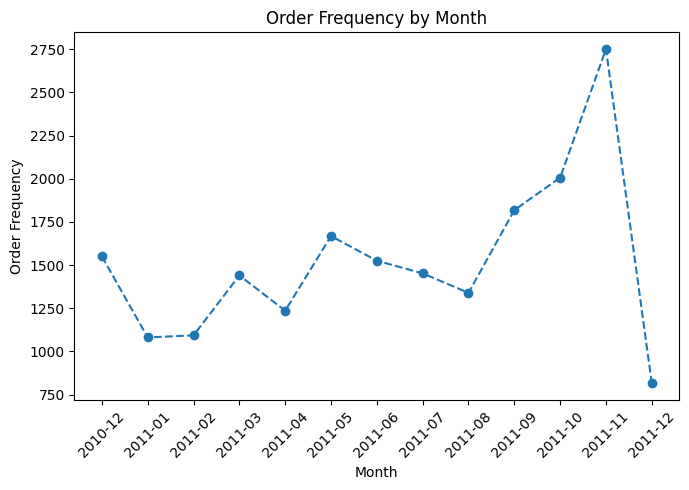

In [45]:
# Visualising Order per Month
plt.figure(figsize=(7, 5))
plt.plot(orders_per_month.index.astype(str), orders_per_month.values, marker='o', linestyle='--')
plt.title("Order Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Order Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Order frequency exhibits a pattern closely aligned with monthly revenue trends. A steady increase is observed across September, October, and November, with these months recording the highest order volumes. This trend is consistent with seasonal demand effects, as consumer purchasing activity typically rises in the lead-up to the Christmas period. Conversely, the earlier months in the year show relatively lower levels of activity, reflecting weaker demand.

Notably, December presents an interesting deviation. Despite having the lowest order frequency (the only month with fewer than 1,000 invoices), it does not correspond to the lowest revenue, instead ranking as the third lowest. This suggests that transactions during this period are of higher value on average, likely driven by last-minute purchases of more expensive items.

Business Implications:
- Lower-demand months provide an opportunity to optimise inventory management, refine marketing strategies, and better anticipate demand fluctuations.
- Targeted promotions and pricing strategies can be implemented during low-order periods to stimulate demand and stabilise sales performance.

#### Revenue by Time (Month, Day of Week, Hour)

Building on the previous monthly revenue analysis, the same comparisons will be performed specifically for the top 10% of customers. This approach will also be applied to revenue by day of the week and by hour. Examining these dimensions for high-value customers allows us to identify how their purchasing behaviour differs from the overall customer base.

In [46]:
# Revenue by Month (top 10%)
rev_per_month_top10 = top_10_percent_cust.groupby('YearMonth')['Revenue'].sum().round(2)
rev_per_month_top10

YearMonth
2010-12    364789.52
2011-01    394811.23
2011-02    262517.90
2011-03    348578.60
2011-04    251167.82
2011-05    397332.06
2011-06    433087.49
2011-07    369625.99
2011-08    411394.82
2011-09    554050.14
2011-10    569216.82
2011-11    631980.59
2011-12    384634.17
Freq: M, Name: Revenue, dtype: float64

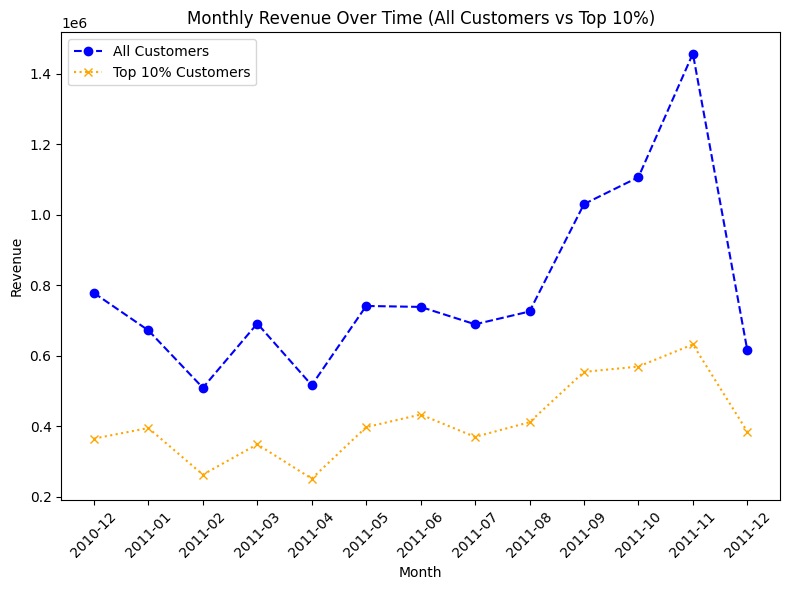

In [47]:
# Visualising Revenue by Month (all customers vs top 10%)
plt.figure(figsize=(8, 6))
plt.plot(rev_per_month.index.astype(str), rev_per_month.values, marker='o', linestyle='--', color='blue', label='All Customers')
plt.plot(rev_per_month_top10.index.astype(str), rev_per_month_top10, marker='x', linestyle=':', color='orange', label='Top 10% Customers')
plt.title("Monthly Revenue Over Time (All Customers vs Top 10%)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Define correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert column to ordered categorical
purchased['DayOfWeek'] = pd.Categorical(purchased['DayOfWeek'], categories=day_order, ordered=True)

The `DayOfWeek` column was ordered from Monday to Sunday to ensure correct chronological presentation in the visualisations.

In [49]:
# Revenue by Day of Week
rev_by_day = purchased.groupby('DayOfWeek')['Revenue'].sum().round(2)
rev_by_day.sort_values(ascending=False)

DayOfWeek
Thursday     2135205.04
Tuesday      2087704.27
Wednesday    1785999.12
Friday       1769747.48
Monday       1685840.29
Sunday        805127.58
Name: Revenue, dtype: float64

In [50]:
# Revenue by Day of Week
rev_by_day_top10 = top_10_percent_cust.groupby('DayOfWeek')['Revenue'].sum().round(2)
rev_by_day_top10.sort_values(ascending=False)

DayOfWeek
Thursday     1212693.90
Tuesday      1092188.98
Wednesday     968114.80
Friday        957879.89
Monday        798142.87
Sunday        344166.71
Name: Revenue, dtype: float64

In [51]:
# Order Frequency by Day of Week
orders_by_day = purchased.groupby('DayOfWeek')['InvoiceNo'].nunique()
orders_by_day.sort_values(ascending=False)

DayOfWeek
Thursday     4209
Wednesday    3668
Tuesday      3509
Friday       3109
Monday       3077
Sunday       2203
Name: InvoiceNo, dtype: int64

In [52]:
# Average order value per day
aov_by_day = rev_by_day / orders_by_day
aov_by_day.round(2).sort_values(ascending=False)

DayOfWeek
Tuesday      594.96
Friday       569.23
Monday       547.88
Thursday     507.30
Wednesday    486.91
Sunday       365.47
dtype: float64

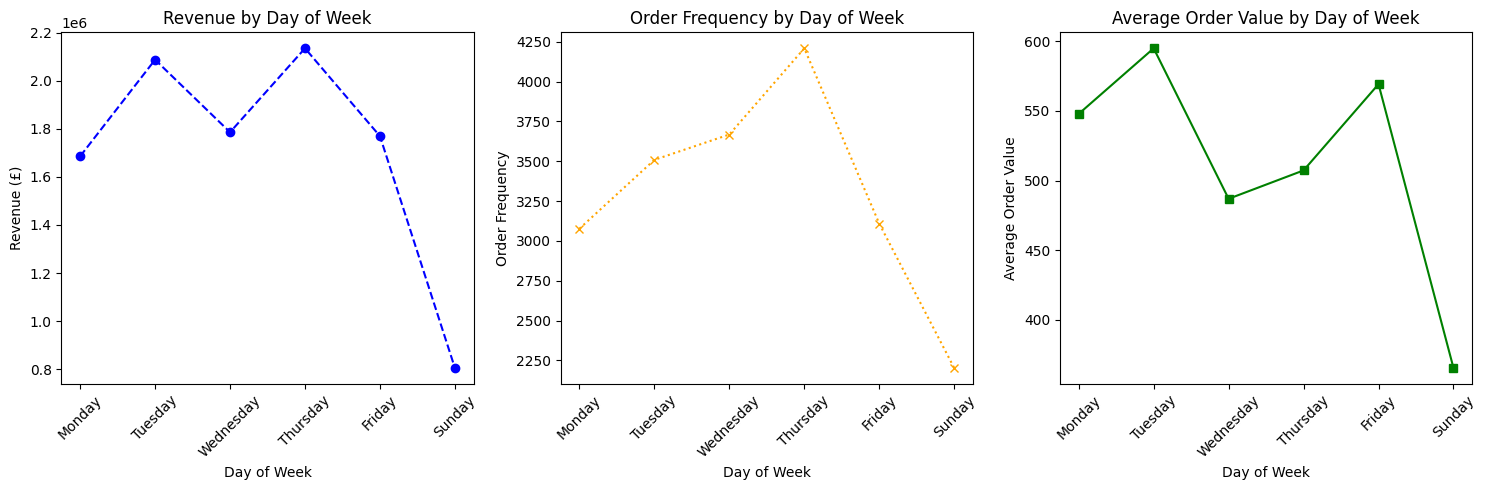

In [53]:
# Plotting Day of Week against Revenue and Order Frequency with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Revenue by Day of Week
axes[0].plot(rev_by_day.index, rev_by_day.values, marker='o', linestyle='--', color='blue')

# Set titles and labels, rotate x-axis ticks for readability
axes[0].set_title("Revenue by Day of Week")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Revenue (£)")
axes[0].tick_params(axis='x', rotation=45)


# Order Frequency by Day of Week
axes[1].plot(orders_by_day.index, orders_by_day.values, marker='x', linestyle=':', color='orange')

# Set titles and labels, rotate x-axis ticks for readability
axes[1].set_title("Order Frequency by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Order Frequency")
axes[1].tick_params(axis='x', rotation=45)

# Average Order Value by Day of Week
axes[2].plot(aov_by_day.index, aov_by_day.values, marker='s', linestyle='-', color='green')

# Set titles and labels, rotate x-axis ticks for readability
axes[2].set_title("Average Order Value by Day of Week")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Average Order Value")
axes[2].tick_params(axis='x', rotation=45)

# Show
plt.tight_layout()
plt.show()

In [54]:
# Revenue by hour
rev_by_hour = purchased.groupby('Hour')['Revenue'].sum()
rev_by_hour_top10 = top_10_percent_cust.groupby('Hour')['Revenue'].sum()

# Average order value by hour
aov_by_hour = purchased.groupby(['Hour', 'InvoiceNo'])['Revenue'].sum().groupby('Hour').mean()
aov_by_hour_top10 = top_10_percent_cust.groupby(['Hour', 'InvoiceNo'])['Revenue'].sum().groupby('Hour').mean()

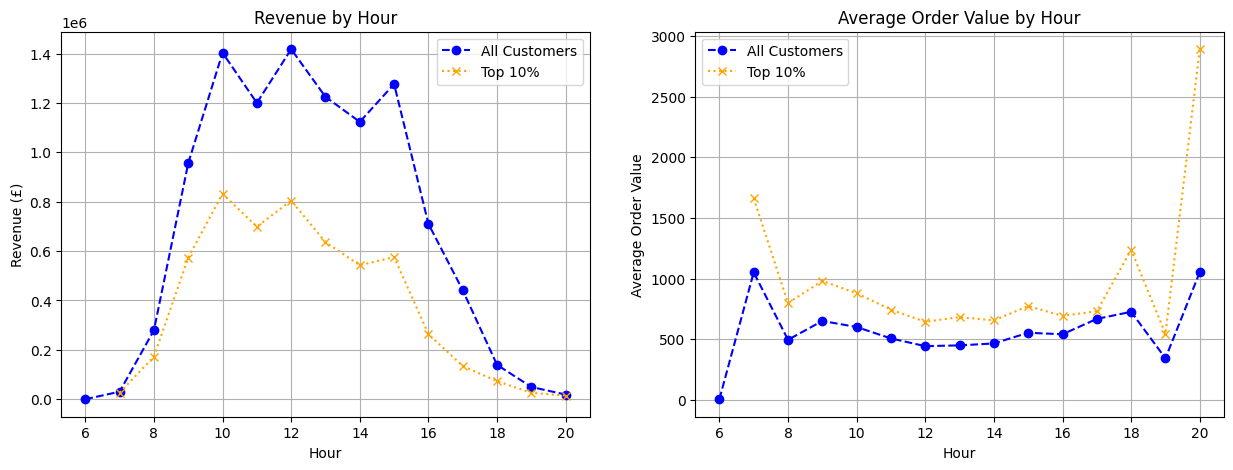

In [55]:
# Plotting Hour by Revenue and Average Order Value (full dataset vs top 10%)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Revenue by Hour (full dataset vs top 10%)
axes[0].plot(rev_by_hour.index, rev_by_hour.values, marker='o', linestyle='--', color='blue')
axes[0].plot(rev_by_hour_top10.index, rev_by_hour_top10.values, marker='x', linestyle=':', color='orange')

# Set titles and labels, add grid for readability
axes[0].set_title("Revenue by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Revenue (£)")
axes[0].legend(['All Customers', 'Top 10%'])
axes[0].grid(True)


# Average Order Value by Hour (full dataset vs top 10%)
axes[1].plot(aov_by_hour.index, aov_by_hour.values, marker='o', linestyle='--', color='blue')
axes[1].plot(aov_by_hour_top10.index, aov_by_hour_top10.values, marker='x', linestyle=':', color='orange')

# Set titles and labels, add grid for readability
axes[1].set_title("Average Order Value by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Average Order Value")
axes[1].legend(['All Customers', 'Top 10%'])
axes[1].grid(True)

##### Revenue by Month:
Nothing new revealed in relation to months and seasonal demand, both DataFrames follow the same pattern and trend. As the data is heavily right-skewed it is likely that as the top 10% of customers contributed to over half the total revenue, that it would set the general pattern.

##### Revenue and Order Frequency by Day of Week:
Analysis of both the full dataset and the top 10% of transactions shows a clear trend in revenue throughout the week. Revenue peaks on Tuesdays and Thursdays, reflecting typical B2B purchasing cycles, while Sunday shows the lowest revenue, indicating minimal business activity on that day.

This trend suggests actionable opportunities: targeted promotions on low-performing days (Sunday–Monday) could stimulate orders, while upselling and bulk incentives on peak days could further maximise revenue.

To understand whether revenue is driven more by order frequency or average value, both metrics were analysed alongside revenue using the full dataset. The results show a consistent pattern:
- Thursday generates the highest number of orders (4,209) and nearly double the revenue compared to Monday, indicating strong volume-driven sales.
- Tuesday, while slightly lower in order frequency (3,509), has the highest average order value (£594.96), suggesting that revenue on this day is more influenced by larger orders rather than sheer volume.
- Friday and Monday show moderate revenue and order frequency, with Friday’s AOV (£569.23) also higher than Thursday, highlighting days where value per order is an important factor.
- Wednesday follows closely in both revenue and order frequency but has a lower AOV (£486.91) compared to Tuesday and Friday.
- Sunday remains the lowest in revenue, order frequency, and AOV (£365.47), reinforcing the minimal B2B activity on weekends.

Notably, Saturday is absent from the dataset. This is not a data processing error, it likely reflects the B2B nature of the business, as most companies do not transact on Saturdays.

Overall, these insights highlight how weekday purchasing patterns can inform strategic decisions on promotions and inventory planning:
- Peak days like Thursday can be leveraged for volume-based incentives.
- High-AOV days like Tuesday may benefit from upselling or bulk-order promotions.
- Low-performing days like Sunday and Monday present opportunities for targeted campaigns to stimulate additional orders.

##### Hourly Revenue & AOV Insights
Revenue peaks during typical B2B business hours, between 9am and 3pm, with low activity early (6–8am) and late (6–8pm). The top 10% of customers follow the same hourly pattern as the overall customer base, reflecting that high-value customers transact predominantly during standard operating hours. Notably, there are occasional spikes in AOV for top customers in the evening, likely due to outlier orders outside typical hours. Overall, peak transaction times are consistent across segments, providing clear guidance for staffing, promotions, and targeted campaigns.

### Cancellations & Returns

This section analyses the impact of cancelled and returned orders on overall business performance. It explores the financial loss associated with cancellations and calculates cancellation rates across different dimensions. The analysis also investigates how cancellations vary by country, product, and time period. These insights help identify potential operational issues and areas for improvement in order fulfilment or product quality.

#### Revenue Lost & Cancellation Rate

Quantifies financial loss due to cancellations and measures their overall impact on business performance.

In [56]:
# Total Revenue lost through cancelled orders
cancelled_rev = cancelled['Revenue'].sum()
print(f"Total Revenue lost through cancelled orders: {cancelled_rev.round(2)}")

Total Revenue lost through cancelled orders: -489701.85


In [57]:
# Number of cancelled orders
no_of_cancellations = cancelled['InvoiceNo'].nunique()

# Total orders
total_orders = purchased['InvoiceNo'].nunique()

# Cancellation Rate
total_cancellation_rate = (no_of_cancellations / total_orders) * 100

# Print
print(f"Total number of orders: {total_orders}")
print(f"Total number of cancelled orders: {no_of_cancellations}")
print(f"Cancellation Rate: {total_cancellation_rate:.2f}%")

Total number of orders: 19775
Total number of cancelled orders: 3453
Cancellation Rate: 17.46%


Cancellations & Returns - Basic Findings:
- Total orders: 19,775
- Cancelled orders: 3,453
- Cancellation rate: 17.46%
- Revenue lost through cancellations: £489,701.85

Key Observations:
- Roughly 1 in 6 orders is cancelled, representing a significant portion of potential revenue.
- The total revenue lost due to cancellations is substantial, highlighting the potential impact of even modest reductions in cancellations.
- These metrics alone don’t explain why cancellations occur, but provide a strong starting point for deeper analysis.

#### Cancellation Rate by Country

Compares cancellation behaviour across regions to identify geographic differences in order reliability.

In [58]:
# Number of cancelled orders by Country
canc_by_country = cancelled.groupby('Country')['InvoiceNo'].nunique()

# Total orders by Country
orders_by_country = purchased.groupby('Country')['InvoiceNo'].nunique()

# Cancellation Rate by Country
cancellation_rate_country = (canc_by_country / orders_by_country) * 100

# Result
cancellation_rate_country = pd.concat([orders_by_country, canc_by_country, cancellation_rate_country], axis=1,
                                      keys=['Orders by Country', 'Cancellations by Country', 'Cancellation Rate by Country (%)'])
cancellation_rate_country.sort_values(by='Cancellation Rate by Country (%)', ascending=False).round(2).head()     # Show first five for readability

,Orders by Country,Cancellations by Country,Cancellation Rate by Country (%)
Country,,,
Saudi Arabia,1,1.0,100.0
Czech Republic,2,2.0,100.0
Malta,5,4.0,80.0
Italy,35,14.0,40.0
USA,5,2.0,40.0


Key Observations:
- High cancellation rates in small-volume countries:
  - Saudi Arabia and Czech Republic both show 100%, but this is based on just 1-2 orders each.
  - Malta (80%) and Italy (40%) also have relatively high rates compared to the overall average.

- Majority of orders come from the UK:
  - The UK accounts for the majority of the total orders, with a cancellation rate of 17.44%, which is close to the overall average.

- Low cancellation rates in some medium-volume countries:
  - Netherlands (3.23%), Norway (6.25%), and Finland (10%) indicate stronger retention relative to order volume.

- Insights:
  - Countries with low order volume can have misleadingly high cancellation rates; analysis should account for this before drawing conclusions.
  - Focus for business impact: Countries with high volume and high cancellation rates (UK, Italy, Germany) are most critical for revenue recovery.

#### Cancellation Rate by Product

Identifies products with high cancellation rates, highlighting potential issues with demand or product quality.

In [59]:
# Products and number of units returned
product_units_cancelled = cancelled.groupby('Description')['Quantity'].sum().sort_values(ascending=True)
product_units_cancelled.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
FAIRY CAKE FLANNEL ASSORTED COLOUR     -3150
PINK BLUE FELT CRAFT TRINKET BOX       -2617
WHITE HANGING HEART T-LIGHT HOLDER     -2578
GIN + TONIC DIET METAL SIGN            -2030
HERB MARKER BASIL                      -1527
FELTCRAFT DOLL MOLLY                   -1447
TEA TIME PARTY BUNTING                 -1424
Name: Quantity, dtype: int64

In [60]:
# Products and Revenue lost through cancellations
product_revenue_lost = cancelled.groupby('Description')['Revenue'].sum()
product_revenue_lost.sort_values(ascending=True).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE          -168469.60
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
REGENCY CAKESTAND 3 TIER               -9722.55
CRUK Commission                        -7933.43
WHITE HANGING HEART T-LIGHT HOLDER     -6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.42
PANTRY CHOPPING BOARD                  -4803.06
DOORMAT FAIRY CAKE                     -4554.90
GIN + TONIC DIET METAL SIGN            -3775.33
TEA TIME PARTY BUNTING                 -3692.95
Name: Revenue, dtype: float64

##### Data Quality Note
The dataset contains entries such as “Discount”, which do not represent actual products but transactional adjustments.
These will be handled during the data cleaning and preprocessing stage, where non-product entries (e.g., discounts, fees, charges) are separated from true product-level data to ensure accurate analysis of sales and returns.

##### Most Returned Products by Quantity
The data shows a highly skewed distribution of returns, with a small number of products accounting for disproportionately large return volumes:
- PAPER CRAFT , LITTLE BIRDIE recorded the highest number of returned units at -80,995, significantly higher than all other products.
- MEDIUM CERAMIC TOP STORAGE JAR followed with -74,494 units returned.
- Other notable products include:
  - ROTATING SILVER ANGELS T-LIGHT HOLDER (-9,376)
  - FAIRY CAKE FLANNEL ASSORTED COLOUR (-3,150)
  - PINK BLUE FELT CRAFT TRINKET BOX (-2,617)

##### Key Insight
Returns are heavily concentrated in a small number of products, suggesting potential issues such as:
- Product quality concerns
- Bulk order cancellations
- Data anomalies or stock adjustments (especially for extremely large negative values)

##### Revenue Lost Through Returns
A similar pattern is observed when analysing revenue loss:

- PAPER CRAFT , LITTLE BIRDIE again dominates with a loss of -£168,469.60, making it the most financially impactful returned product by a wide margin.
- MEDIUM CERAMIC TOP STORAGE JAR contributes a further -£77,479.64 in lost revenue.
- Other significant contributors include:
  - REGENCY CAKESTAND 3 TIER (-£9,722.55)
  - WHITE HANGING HEART T-LIGHT HOLDER (-£6,624.30)
  - FAIRY CAKE FLANNEL ASSORTED COLOUR (-£6,591.42)

##### Key Insight
A small number of products account for the majority of financial losses from returns, indicating a classic Pareto (80/20) effect where a few products drive most of the negative revenue impact.

##### Business Implications
From a business perspective, these findings highlight key opportunities:
- Investigate top-returned SKUs to identify root causes (quality issues, packaging, supplier problems, or demand misalignment).
- Audit extreme negative transactions to distinguish genuine returns from operational adjustments.
- Prioritise high-impact products such as “PAPER CRAFT , LITTLE BIRDIE” and “MEDIUM CERAMIC TOP STORAGE JAR” for quality review, as improvements here would significantly reduce revenue loss.
- Consider implementing return rate monitoring dashboards to continuously track product performance.

#### Cancellation Trends Over Time

Tracks how cancellations change over time to identify operational or seasonal influences.

In [61]:
# Cancellations by Month
monthly_returns = cancelled.groupby('YearMonth')['InvoiceNo'].nunique()
monthly_returns

YearMonth
2010-12    302
2011-01    247
2011-02    195
2011-03    282
2011-04    220
2011-05    269
2011-06    301
2011-07    235
2011-08    243
2011-09    304
2011-10    316
2011-11    401
2011-12    138
Freq: M, Name: InvoiceNo, dtype: int64

In [62]:
# Monthly cancellation rate
monthly_cancellation_rate = ((monthly_returns / purchased.groupby('YearMonth')['InvoiceNo'].nunique()) * 100).round(2)
monthly_cancellation_rate

YearMonth
2010-12    19.48
2011-01    22.85
2011-02    17.84
2011-03    19.58
2011-04    17.80
2011-05    16.13
2011-06    19.74
2011-07    16.18
2011-08    18.15
2011-09    16.72
2011-10    15.75
2011-11    14.58
2011-12    16.91
Freq: M, Name: InvoiceNo, dtype: float64

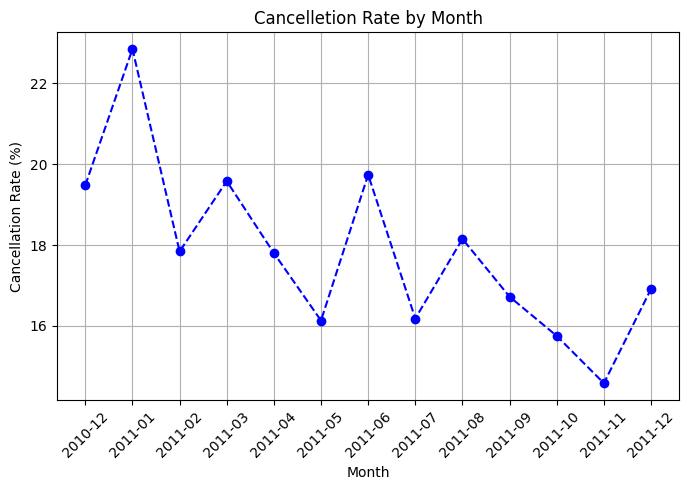

In [63]:
# Visualising Cancellations Rate by Month
plt.figure(figsize=(7, 5))
plt.plot(monthly_cancellation_rate.index.astype(str), monthly_cancellation_rate.values, marker='o', linestyle='--', color='blue')
plt.title("Cancelletion Rate by Month")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Cancellation rates show clear seasonality, with a peak observed in January 2011 following the Christmas trading period (22.85%). This spike is likely driven by post-holiday returns and stock adjustments, particularly in a B2B retail context where bulk ordering is common.

Following this peak, cancellation rates gradually decline and stabilise throughout mid-2011, settling within a narrower range of approximately 15–18%, indicating more consistent purchasing behaviour outside of seasonal volatility.

The lowest cancellation rate occurs in November 2011 (14.58%), which may reflect pre-Christmas stock accumulation and potential lag effects in return processing. Overall, the data suggests strong seasonality in returns with a pronounced post-holiday correction period.

### Product Analysis

This section focuses on understanding product-level relationships and purchasing patterns. It explores which products are frequently bought together through pairing analysis. This helps identify opportunities for cross-selling and bundling strategies. The insights generated can support improved product recommendations and increase overall sales efficiency.

#### Product Pairing Analysis

Identifies products frequently purchased together to support cross-selling and recommendation strategies.

In [64]:
# Import library
from itertools import combinations

# DataFrame keeping necessary columns
prod_analysis_df = purchased[['Description', 'InvoiceNo']]

# Build baskets (each invoice = list of unique products)
basket = prod_analysis_df.groupby('InvoiceNo')['Description'].apply(lambda x: list(set(x)))

# Count pairs
pair_counts = {}

for products in basket:
    for pair in combinations(sorted(products), 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

# Convert to DataFrame
pairs_df = pd.DataFrame(pair_counts.items(), columns=['Product Pair', 'Count'])

# Sort strongest pairs
pairs_df = pairs_df.sort_values(by='Count', ascending=False)

# Prevent truncation by displaying full text in pandas output
pd.set_option('display.max_colwidth', None)
pairs_df.head(10)

,Product Pair,Count
12400,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT)",825
99453,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",767
6465,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)",724
17309,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE RED PAISLEY)",680
7928,"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROSPOT)",641
113,"(ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE RED )",640
906839,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER)",632
3456,"(LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROSPOT)",606
1058895,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER )",598
1261,"(JUMBO BAG BAROQUE BLACK WHITE, JUMBO BAG RED RETROSPOT)",585


A market basket analysis was conducted to identify frequently co-purchased products and uncover cross-selling opportunities.

Key Insights
- JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT was the strongest pair (825 occurrences), showing high demand for similar storage products.
- TEA CUP & SAUCER sets (e.g., GREEN & ROSES variants) frequently appear together, indicating strong preference for matching designs.
- LUNCH BAGS and ALARM CLOCKS show strong pairing across colour/design variants, suggesting multi-item or gift purchases.
- Storage and homeware items are commonly bought in combination, highlighting strong category-level bundling behaviour.

Business Impact
- Strong opportunity for product bundling and “frequently bought together” recommendations.
- Clear evidence of variant-based purchasing behaviour (colour/design preferences).
- Potential for improved cross-sell strategy and product placement.

Conclusion

Customers tend to purchase complementary or variant products within the same category, making this dataset highly suitable for recommendation systems and bundling strategies.

### Customer Analysis

This section examines customer behaviour to understand purchasing patterns, value, and engagement levels. It analyses order frequency and customer lifetime value to identify high-value and loyal customers. The RFM segmentation technique is used to group customers based on recency, frequency, and monetary value. These insights support targeted marketing strategies and customer retention efforts.

#### Customer Order Frequency

Measures how often customers place orders to distinguish between one-time and repeat buyers.

In [65]:
# Order Frequency per Customer
orders_per_cust = purchased.groupby('CustomerID')['InvoiceNo'].nunique()

# Merge with top 10%
rev_top_10_percent_cust = top_10_percent_cust.groupby('CustomerID')['Revenue'].sum().reset_index()
top_10_cust_summary = rev_top_10_percent_cust.merge(orders_per_cust, on='CustomerID')

sorted_revenue = top_10_cust_summary.sort_values(by='Revenue', ascending=False)
sorted_revenue.head()

,CustomerID,Revenue,InvoiceNo
197,14646.0,279138.02,72
423,18102.0,259657.30,60
382,17450.0,194550.79,46
315,16446.0,168472.50,2
212,14911.0,136222.52,198


In [66]:
# Average number of orders per customer (full dataset)
print(f"Average number of orders per customer for all customers: {round(orders_per_cust.mean())}")

# Average number of orders per customer (top 10%)
print(f"Average number of orders per customer among the top 10% of customers: {round(top_10_cust_summary['InvoiceNo'].mean())}")

# Average number of orders for the top 100 revenue-generating customers
print(f"Average number of orders among the top 100 highest revenue customers: {round(sorted_revenue['InvoiceNo'].iloc[:100].mean())}")

Average number of orders per customer for all customers: 4
Average number of orders per customer among the top 10% of customers: 16
Average number of orders among the top 100 highest revenue customers: 31


Order frequency is a key metric for understanding whether revenue is driven by one-time high-value purchases or repeat transactions from loyal customers.

A clear trend emerges: higher-value customers tend to have higher order frequency.

Across the full dataset, customers place an average of 4 orders. However, within the top 10% of customers, who contribute over half of total revenue, the average rises significantly to 16 orders. This increases further among the top 100 customers, who place an average of 31 orders.

Key insight:
- Revenue is strongly driven by customer loyalty and repeat purchasing behaviour, rather than isolated high-value transactions.

The findings suggest that the most effective strategy is to:
- Prioritise customer retention over one-time sales.
- Encourage repeat purchases through loyalty incentives and engagement strategies.
- Focus on building long-term customer relationships, where consistent purchasing drives higher lifetime value.

#### Customer Lifetime Value

Estimates total customer value over time to identify the most profitable customer segments.

In [67]:
# Finding a customer's first & last purchase (full dataset vs top 10%)
customer_lifetime = purchased.groupby('CustomerID')['Date'].agg(['min','max'])
top_10_customer_lifetime = top_10_percent_cust.groupby('CustomerID')['Date'].agg(['min','max'])

# Calculating number of days for Customer Lifetime (full dataset vs top 10%)
customer_lifetime['lifetime_days'] = (customer_lifetime['max'] - customer_lifetime['min']).dt.days
top_10_customer_lifetime['lifetime_days'] = (top_10_customer_lifetime['max'] - top_10_customer_lifetime['min']).dt.days

# DataFrame of Customer Lifetime metrics
customer_lifetime_summary = pd.DataFrame({
    'full_dataset': customer_lifetime['lifetime_days'].describe(),
    'top_10%': top_10_customer_lifetime['lifetime_days'].describe()
})
customer_lifetime_summary.round()

,full_dataset,top_10%
count,4334.0,434.0
mean,131.0,296.0
std,132.0,92.0
min,0.0,0.0
25%,0.0,266.0
50%,92.0,336.0
75%,252.0,360.0
max,373.0,373.0


In [68]:
# Merging total Revenue by Customer with Customer Lifetime
customer_lifetime = customer_lifetime.merge(rev_per_cust[['CustomerID', 'Revenue']], on='CustomerID', how='left')
top_10_customer_lifetime = top_10_customer_lifetime.merge(rev_per_cust[['CustomerID', 'Revenue']], on='CustomerID', how='left')

# Adding a Revenue per day column
customer_lifetime['rev_per_day'] = customer_lifetime['Revenue'] / customer_lifetime['lifetime_days'].replace(0,1)
top_10_customer_lifetime['rev_per_day'] = top_10_customer_lifetime['Revenue'] / top_10_customer_lifetime['lifetime_days'].replace(0,1)

# Average Revenue per day for all customers
print(f"Average Revenue per day (all customers): £{customer_lifetime['rev_per_day'].mean().round(2)}")
print(f"Average Revenue per day (top 10% customers): £{top_10_customer_lifetime['rev_per_day'].mean().round(2)}")

Average Revenue per day (all customers): £177.79
Average Revenue per day (top 10% customers): £468.19


To understand whether high revenue is driven by large one-off purchases or frequent spending, customer lifetime was calculated as the difference between each customer’s maximum and minimum transaction dates.

The analysis shows that high-value customers tend to have significantly longer engagement periods. Across the full dataset, 25% of customers were one-time buyers. In contrast, among the top 10% of customers, the 25th percentile of customer lifetime was 266 days. Additionally, the average customer lifetime for the top 10% was more than double that of the overall dataset.

It is important to note that the full dataset contains a large proportion of one-time buyers (lifetime = 1 day), which can artificially inflate the `rev_per_day` metric. Despite this, the average `rev_per_day` for the full dataset (£177.79) remains substantially lower than that of the top 10% (£468.19). This indicates that high-value customers not only spend more overall, but also generate revenue at a faster and more consistent rate.

Key Insights:
- Longer customer retention is strongly associated with higher overall revenue.
- High-value customers are characterised by both sustained engagement and higher spending intensity.
- Revenue growth is driven by a combination of repeat purchases and faster spending behaviour, not just large single transactions.

Marketing Strategy Implications:
- Focus on increasing customer retention through loyalty programmes and personalised incentives.
- Encourage repeat purchases via targeted promotions and engagement campaigns.

#### RFM Segmentation

Segments customers based on Recency, Frequency, and Monetary value to classify engagement and value levels.

In [69]:
# Most recent date (1 day after last transaction)
snapshot_date = purchased['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM calculation
rfm = purchased.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'Revenue': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Score (quartiles)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['R'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])

# Combine scores
rfm['RFM_Score'] = rfm[['R','F','M']].astype(str).sum(axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,F,M,R,RFM_Score
0,12346.0,326,1,77183.60,1,4,1,114
1,12347.0,2,7,4310.00,4,4,4,444
2,12348.0,75,4,1437.24,3,3,2,233
3,12349.0,19,1,1457.55,1,3,3,313
4,12350.0,310,1,294.40,1,1,1,111


In [70]:
# User defined function (customer segments)
def segment_customer(row):
    if row['R'] == 4 and row['F'] == 4:
        return 'VIP Customers'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Loyal Customers'
    elif row['R'] == 4 and row['F'] <= 2:
        return 'New Customers'
    elif row['R'] <= 2 and row['F'] >= 3:
        return 'At Risk Loyal'
    elif row['R'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [71]:
# Number of customers per segment
cust_segment_counts = rfm['Segment'].value_counts()
cust_segment_counts

Segment
At Risk            1516
Loyal Customers     921
At Risk Loyal       651
VIP Customers       595
Others              432
New Customers       219
Name: count, dtype: int64

In [72]:
# Revenue contribution per segment
rev_per_seg = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).round(2)
rev_per_seg

Segment
VIP Customers      4481819.11
Loyal Customers    1992756.68
At Risk Loyal      1022073.22
At Risk             771582.69
New Customers       279594.89
Others              211031.49
Name: Monetary, dtype: float64

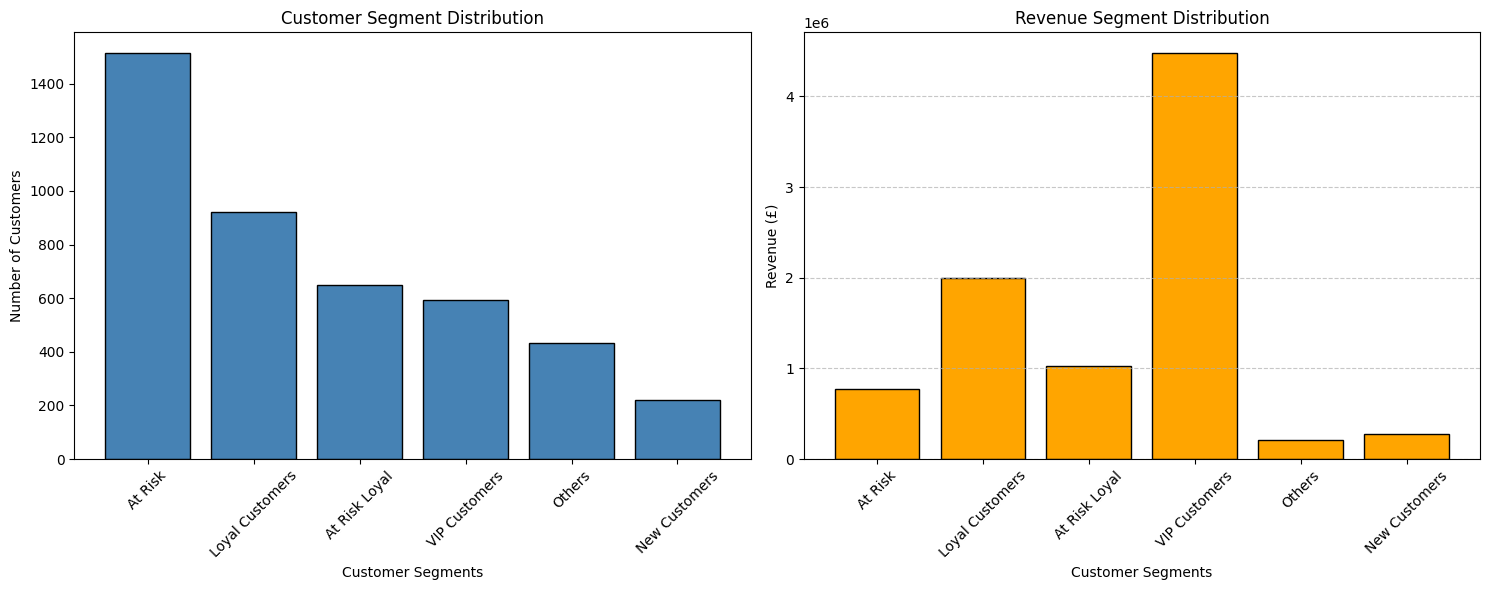

In [73]:
# Use customer count order as reference
order = cust_segment_counts.index

# Reindex revenue to match
rev_per_seg = rev_per_seg.reindex(order)

# Plotting Number of Customers and Revenue by Segments with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Number of Customers by Segment
axes[0].bar(cust_segment_counts.index, cust_segment_counts.values, color='steelblue', edgecolor='black')

# Set titles and labels, rotate x-axis ticks for readability
axes[0].set_title("Customer Segment Distribution")
axes[0].set_xlabel("Customer Segments")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis='x', rotation=45)


# Order Frequency by Day of Week
axes[1].bar(rev_per_seg.index, rev_per_seg.values, color='orange', edgecolor='black')

# Set titles and labels, rotate x-axis ticks for readability
axes[1].set_title("Revenue Segment Distribution")
axes[1].set_xlabel("Customer Segments")
axes[1].set_ylabel("Revenue (£)")
axes[1].tick_params(axis='x', rotation=45)

# Show
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [74]:
# Average behaviour per segment
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round()

,Recency,Frequency,Monetary
Segment,,,
At Risk,186.0,1.0,509.0
At Risk Loyal,117.0,4.0,1570.0
Loyal Customers,24.0,5.0,2164.0
New Customers,10.0,2.0,1277.0
Others,33.0,1.0,488.0
VIP Customers,7.0,14.0,7532.0


Customers were grouped into behavioural segments based on their RFM scores. The distribution of customers across segments is shown below:
- At Risk	- 1,516
- Loyal Customers	- 921
- At Risk Loyal - 651
- VIP Customers - 595
- Others - 432
- New Customers - 219

Key Insight - Customer Distribution
- The largest segment is At Risk customers, indicating a significant portion of customers have not purchased recently.
- VIP Customers, although smaller in number, represent the highest-value group.
- A meaningful proportion of customers fall into transitional groups such as At Risk Loyal, indicating potential churn risk among previously active users.

Key Insight - Revenue Concentration
- VIP Customers generate the highest revenue, despite being a relatively small segment. 
- Together, VIP and Loyal Customers contribute the majority of total revenue, highlighting strong revenue concentration in high-value groups.
- Lower-value segments contribute significantly less revenue individually, but represent important future growth or churn risk areas.

Key Insight - Behavioural Patterns
- VIP Customers are highly active, purchasing frequently and contributing the highest monetary value, with very recent activity.
- Loyal Customers demonstrate consistent engagement and strong spending behaviour.
- At Risk Customers have not purchased recently (high recency) and show very low engagement.
- At Risk Loyal Customers previously showed strong engagement but are showing early signs of churn.
- New Customers have very recent activity but lower frequency, indicating early lifecycle stage.

Overall Business Insights
- Revenue is heavily concentrated in VIP and Loyal Customers, highlighting the importance of retention strategies for high-value users.
- A large portion of the customer base is classified as At Risk, signalling potential churn and revenue leakage.
- There is a clear opportunity to convert New Customers into Loyal Customers through onboarding and engagement strategies.
- The At Risk Loyal segment is critical, as it represents previously valuable customers who are beginning to disengage.

Recommended Business Actions
- VIP Customers
  - Loyalty rewards, exclusive offers, retention focus
- Loyal Customers
  - Upselling and cross-selling campaigns
- New Customers
  - Onboarding journey and first-purchase incentives
- At Risk Loyal
  - Win-back campaigns and personalised re-engagement
- At Risk
  - Discount reactivation campaigns
- Others
  - Low-cost automated marketing